__SC24219070 朱越__

# 导入库与加载数据

- 选取了Resnet56_CIFAR10预训练网络用于攻击。

- 白盒攻击使用的CW定向攻击。

- 黑盒攻击选用Resnet20_CIFAR10预训练网络作为代理网络，使用的FGSM攻击。

## 加载必要的库，然后加载CIFAR10数据集

由于pytorchcv提供的预训练网络都是使用标准化的数据训练的，所以载入的数据集也要做标准化。

In [1]:
import torch
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import CIFAR10
from pytorchcv.model_provider import get_model
from torchinfo import summary
import matplotlib.pyplot as plt
from tqdm import *

In [2]:
#预训练的网络参数使用了标准化的数据集，因此在预处理中引入标准化
mean = [0.4914, 0.4822, 0.4465]
std = [0.2470, 0.2435, 0.2616]
transform = transforms.Compose([
    transforms.ToTensor(),  # 自动缩放到 [0,1]
    transforms.Normalize(mean, std)  #执行标准化
])
#加载数据集，由于是预先下载好的，所以download使用False
testset = CIFAR10(root='datas', train=False, download=False, transform=transform)

## 加载预训练的网络

In [3]:
#加载网络参数
def ptcv_get_model(name, model_path):
    net = get_model(name, pretrained=False)
    state_dict = torch.load(model_path)
    net.load_state_dict(state_dict)
    return net

In [4]:
#加载网络，网络权重也都下载好了，使用了自定义的加载函数
#resnet56_cifar10预训练网络的Test Accuracy测试结果为95.32%
net = ptcv_get_model("resnet56_cifar10", "./models/resnet56_cifar10-0452-628c42a2.pth")
net.eval()
summary(net)

Layer (type:depth-idx)                             Param #
CIFARResNet                                        --
├─Sequential: 1-1                                  --
│    └─ConvBlock: 2-1                              --
│    │    └─Conv2d: 3-1                            432
│    │    └─BatchNorm2d: 3-2                       32
│    │    └─ReLU: 3-3                              --
│    └─Sequential: 2-2                             --
│    │    └─ResUnit: 3-4                           4,672
│    │    └─ResUnit: 3-5                           4,672
│    │    └─ResUnit: 3-6                           4,672
│    │    └─ResUnit: 3-7                           4,672
│    │    └─ResUnit: 3-8                           4,672
│    │    └─ResUnit: 3-9                           4,672
│    │    └─ResUnit: 3-10                          4,672
│    │    └─ResUnit: 3-11                          4,672
│    │    └─ResUnit: 3-12                          4,672
│    └─Sequential: 2-3                           

先使用原始网络执行一下识别，看看初始准确率有多少。

In [5]:
correct = 0  #识别准确个数
test_loader = DataLoader(testset, 1, shuffle=False)
for data, label in tqdm(test_loader):
    output = net(data)
    init_pred = output.max(1, keepdim=True)[1]  # get the index of the max log-probability
    if init_pred.item() == label.item():  #识别正确
        correct += 1
acc = correct / float(len(test_loader))
print(f"Test Accuracy = {acc}")

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [05:47<00:00, 28.77it/s]

Test Accuracy = 0.9532


可以看到预训练的resnet56_cifar10网络的识别准确率达到了95.32%。

# 白盒攻击

## 定义迭代中用到的参数、损失函数和优化方法

- 攻击之前检查是否识别正确，识别错误的就没必要攻击了。

- 将识别结果中概率次大的作为目标，执行CW定向攻击。

- 结果同时计算识别准确率和攻击成功率。

In [6]:
# 主要参数
lr = 0.01  # 学习率
max_iter = 100  # 最大迭代次数
c = 1  # 平衡松弛函数的超参数
kappa = 1  # 松弛函数中的置信度参数
epsilon = 8 / 255  # L无穷范数限制

In [7]:
def CW_Attack(net, data, label, lr, max_iter, c, kappa, epsilon, mean, std):
    #在攻击之前先检查一下是否正确识别
    output = net(data)
    init_pred = output.max(1, keepdim=True)[1]  # get the index of the max log-probability
    # If the initial prediction is wrong, don't bother attacking, just move on
    if init_pred.item() != label.item():
        return data, label

    #设置一个目标，这里得到的是概率值次大的索引
    target = torch.max(output[:, [l for l in range(10) if l != label]], dim=1)[1]
    # 初始化扰动变量（需梯度跟踪）
    delta = torch.zeros_like(data, requires_grad=True)
    optimizer = torch.optim.SGD([delta], lr=lr)
    
    for i in range(max_iter):
        optimizer.zero_grad()
        # 生成对抗样本
        data_denorm = data * torch.tensor(std).view(1, 3, 1, 1) + torch.tensor(mean).view(1, 3, 1, 1)
        perturbed_data = data_denorm + delta
        adv_image = (perturbed_data - torch.tensor(mean).view(1, 3, 1, 1)) / torch.tensor(std).view(1, 3, 1, 1)
        # 模型预测
        logits = net(adv_image)
        # 计算松弛函数
        logits_target = logits[:, target]
        logits_other = torch.max(logits[:, [i for i in range(logits.shape[1]) if i != target]], dim=1)[0]
        f6 = torch.clamp(logits_other - logits_target + kappa, min=0)  #PPT写的f6，所以这里也用f6
        # 优化目标
        loss = c * f6
        #早停减少迭代次数
        #在这里早停使用的是上一轮优化的delta，经过了上一轮的clamp操作
        if loss <= 1e-4:
            break
        # 反向传播和优化
        loss.backward()
        optimizer.step()
        # 投影操作：将扰动裁剪到[-epsilon, epsilon]范围内
        delta.data.clamp_(-epsilon, epsilon)

    # 最终对抗样本
    data_denorm = data * torch.tensor(std).view(1, 3, 1, 1) + torch.tensor(mean).view(1, 3, 1, 1)
    perturbed_data = data_denorm + delta.detach()  #抛弃梯度信息
    adv_image = (perturbed_data - torch.tensor(mean).view(1, 3, 1, 1)) / torch.tensor(std).view(1, 3, 1, 1)
    
    return adv_image, target

再定义一下可视化的函数。

In [8]:
classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

def attack_display(orig_pred, image, adv_pred, adv_image, classes):
    image_denorm = image * torch.tensor(std).view(1, 3, 1, 1) + torch.tensor(mean).view(1, 3, 1, 1)
    image_denorm.data.clamp_(0, 1)
    adv_image_denorm = adv_image * torch.tensor(std).view(1, 3, 1, 1) + torch.tensor(mean).view(1, 3, 1, 1)
    adv_image_denorm.data.clamp_(0, 1)
    
    plt.figure(figsize=(6, 3))
    
    plt.subplot(1, 2, 1)
    plt.title(f"Original\nLabel: {classes[orig_pred]}")
    plt.imshow(image_denorm.squeeze().permute(1, 2, 0), interpolation='hanning')
    plt.axis("off")
    
    plt.subplot(1, 2, 2)
    plt.title(f"Adversarial\nLabel: {classes[adv_pred]}")
    plt.imshow(adv_image_denorm.squeeze().permute(1, 2, 0), interpolation='hanning')
    plt.axis("off")
    
    plt.show()

先执行一次攻击看看效果：

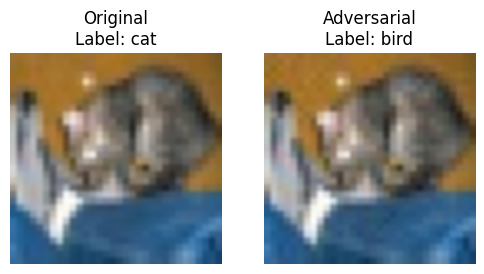

In [9]:
test_loader = DataLoader(testset, 1, shuffle=False)
for data, label in test_loader:
    adv_image, target = CW_Attack(net, data, label, lr, max_iter, c, kappa, epsilon, mean, std)
    # 计算正确率
    adv_logits = net(adv_image)
    adv_pred = adv_logits.max(1, keepdim=True)[1]
    if adv_pred.item() == target.item():  #攻击成功
        attack_display(label, data, target, adv_image, classes)
        break

可以看到，在几乎没有改变图像的条件下，实现了网络的误判。

## 开始攻击！

In [10]:
correct = 0  #识别准确个数
success = 0  #攻击成功个数（定向）

#依次攻击，所以使用前面batch_size为1的test_loader
for data, label in tqdm(test_loader):
    adv_image, target = CW_Attack(net, data, label, lr, max_iter, c, kappa, epsilon, mean, std)
    # 计算正确率
    adv_logits = net(adv_image)
    adv_pred = adv_logits.max(1, keepdim=True)[1]
    if adv_pred.item() == label.item():  #识别正确
        correct += 1
    if adv_pred.item() == target.item():  #攻击成功
        success += 1

# Calculate final accuracy for this epsilon
final_acc = correct / float(len(test_loader))
final_suc = success / float(len(test_loader))
print(f"Test Accuracy = {final_acc}, Attack Success Rate = {final_suc}")

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [1:24:39<00:00,  1.97it/s]

Test Accuracy = 0.0878, Attack Success Rate = 0.9511


可以看到，CW定向攻击的成功率达到95.11%，原网络识别准确率仅8.78%，达到任务要求。

# 黑盒攻击

## 定义迭代中用到的参数和噪声生成方法。

- 这部分FGSM是根据任务文档改的。

- 使用一个Resnet20_CIFAR10的预训练网络作为影子网络。

In [11]:
from torch.nn import NLLLoss

#加载网络，网络权重也都下载好了，使用了自定义的加载函数
black_box_net = net
shadow_net = ptcv_get_model("resnet20_cifar10", "./models/resnet20_cifar10-0597-9b0024ac.pth")
# Set the model in evaluation mode. In this case this is for the Dropout layers
black_box_net.eval()
shadow_net.eval()
summary(net)

Layer (type:depth-idx)                             Param #
CIFARResNet                                        --
├─Sequential: 1-1                                  --
│    └─ConvBlock: 2-1                              --
│    │    └─Conv2d: 3-1                            432
│    │    └─BatchNorm2d: 3-2                       32
│    │    └─ReLU: 3-3                              --
│    └─Sequential: 2-2                             --
│    │    └─ResUnit: 3-4                           4,672
│    │    └─ResUnit: 3-5                           4,672
│    │    └─ResUnit: 3-6                           4,672
│    │    └─ResUnit: 3-7                           4,672
│    │    └─ResUnit: 3-8                           4,672
│    │    └─ResUnit: 3-9                           4,672
│    │    └─ResUnit: 3-10                          4,672
│    │    └─ResUnit: 3-11                          4,672
│    │    └─ResUnit: 3-12                          4,672
│    └─Sequential: 2-3                           

FGSM方法直接引用了范例。

In [12]:
# FGSM attack code
def fgsm_attack(image, epsilon, data_grad):
    # Collect the element-wise sign of the data gradient
    sign_data_grad = data_grad.sign()
    # Create the perturbed image by adjusting each pixel of the input image
    perturbed_image = image + epsilon*sign_data_grad
    #这里的归一化替换为了标准化，在攻击外部
    # Return the perturbed image
    return perturbed_image

黑盒攻击方法，返回的是受到扰动的图像。

In [13]:
def black_box_attack(data, label, epsilon):
    # Set requires_grad attribute of tensor. Important for Attack
    data.requires_grad = True

    #利用影子网络识别并提取梯度
    # Forward pass the data through the model
    output = shadow_net(data)
    #由于是黑盒攻击，所以不排除识别错误的项目了
    # Calculate the loss
    criterion = NLLLoss()
    loss = criterion(output, label)
    # Zero all existing gradients
    shadow_net.zero_grad()
    # Calculate gradients of model in backward pass
    loss.backward()
    # Collect ``datagrad``
    data_grad = data.grad.data
    #这里的反标准化改写了，没有使用自定义函数
    data_denorm = data * torch.tensor(std).view(1, 3, 1, 1) + torch.tensor(mean).view(1, 3, 1, 1)
    # Call FGSM Attack
    perturbed_data = fgsm_attack(data_denorm, epsilon, data_grad)
    #再执行标准化
    turbed_image = (perturbed_data - torch.tensor(mean).view(1, 3, 1, 1)) / torch.tensor(std).view(1, 3, 1, 1)
    data.requires_grad_(False)
    
    return turbed_image.detach()

先攻击一次看看效果。

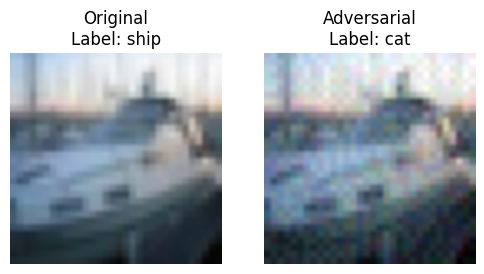

In [14]:
#这里的L无穷范数epsilon上面定义过了，所以直接使用了
test_loader = DataLoader(testset, 1, shuffle=False)
for data, label in test_loader:
    turbed_image = black_box_attack(data, label, epsilon)
    
    #扰动后的图像用于攻击黑盒网络
    # Re-classify the perturbed image
    output = black_box_net(turbed_image)
    # Check for success
    final_pred = output.max(1, keepdim=True)[1] # get the index of the max log-probability
    if final_pred.item() != label.item():
        attack_display(label, data, final_pred, turbed_image, classes)
        break

可以看出，攻击在引入较小噪声的条件下，实现了网络的误判。

## 开始攻击！

In [15]:
# Accuracy counter
correct = 0

# Loop over all examples in test set
for data, label in tqdm(test_loader):
    turbed_image = black_box_attack(data, label, epsilon)

    #扰动后的图像用于攻击黑盒网络
    # Re-classify the perturbed image
    output = black_box_net(turbed_image)
    # Check for success
    final_pred = output.max(1, keepdim=True)[1] # get the index of the max log-probability
    if final_pred.item() == label.item():
        correct += 1

# Calculate final accuracy for this epsilon
final_acc = correct/float(len(test_loader))
print(f"Test Accuracy = {correct} / {len(test_loader)} = {final_acc}")

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [10:34<00:00, 15.75it/s]

Test Accuracy = 5309 / 10000 = 0.5309


可以看到FGSM攻击后识别准确率仅53.09%，有明显的下降。

# 总结与反思

- 这次的实验先做了黑盒后做的白盒，因为黑盒直接引用了文件给出的例程，代理网络也可以直接下载，感觉很方便呢。

- 为了区别两种攻击的工作，所以白盒攻击尝试了CW这种非梯度的方法。

- CW方法的松弛函数选取跟攻击效果直接相关，一开始尝试使用的是f1=-loss+1的目标函数（因为图省力，选择了非定向的），调参了很久Accuracy都可以保持在50%左右，一度以为pytorchcv提供的网络是有防御的x_x

- 所以为了使报告花样更多一点，改用了效果超好的定向方法！